In [1]:
using JuMP
using HiGHS
using Plots

In [2]:
model = Model(HiGHS.Optimizer)

@variable(model, 0<= pattern[1:2] <= 4, Int)

@constraint(model, 5*pattern[1] + 3*pattern[2] >= 15)
@constraint(model, 2*pattern[1] + 5*pattern[2] >= 10)
@objective(model, Min, pattern[1] + pattern[2])

optimize!(model)

Running HiGHS 1.15.1 (git hash: 04024d701f): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
Using BLAS: Apple Accelerate 
MIP has 2 rows; 2 cols; 4 nonzeros; 2 integer variables (0 binary)
Coefficient ranges:
  Matrix  [2e+00, 5e+00]
  Cost    [1e+00, 1e+00]
  Bound   [4e+00, 4e+00]
  RHS     [1e+01, 2e+01]
Presolving model
2 rows, 2 cols, 4 nonzeros 0s
2 rows, 2 cols, 4 nonzeros 0s
Presolve reductions: rows 2(-0); columns 2(-0); nonzeros 4(-0) 
Objective function is integral with scale 1

Solving MIP model with:
   2 rows
   2 cols (0 binary, 2 integer, 0 implied int., 0 continuous, 0 domain fixed)
   4 nonzeros
   Thread count 4 (of 8 threads). Using 1 max workers. Parallel search off

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node;

In [3]:
if termination_status(model) != MOI.OPTIMAL
    println("No optimal solution found.")
else
    opt_val = objective_value(model)
    println("Optimal objective value: ", opt_val)
    println("Optimal solution: ", value.(pattern))

    # Find any additional solutions with the same optimal value
    @constraint(model, pattern[1] + pattern[2] == opt_val)

    solutions = []

while true
        optimize!(model)
        if termination_status(model) != MOI.OPTIMAL
            break
        end

        # Round to avoid floating point precision issues (e.g., 2.99999999)
        current_sol = round.(Int, value.(pattern))
        push!(solutions, current_sol)

        # Create binary variables to indicate if a value is strictly greater or less
        gt = @variable(model, [1:2], Bin)
        lt = @variable(model, [1:2], Bin)
        
        for i in 1:2
            # Big-M value: Max possible difference is 4. We use M = 5 to be safe.
            
            # If gt[i] == 1, then pattern[i] must be >= current_sol[i] + 1
            @constraint(model, pattern[i] - current_sol[i] >= 1 - 5 * (1 - gt[i]))
            
            # If lt[i] == 1, then pattern[i] must be <= current_sol[i] - 1
            @constraint(model, current_sol[i] - pattern[i] >= 1 - 5 * (1 - lt[i]))
        end

        # The core no-good cut: At least one variable MUST be strictly greater or strictly less 
        # than the previous solution.
        @constraint(model, sum(gt) + sum(lt) >= 1)
    end
end

solutions

Optimal objective value: 4.0
Optimal solution: [3.0, 1.0]
MIP has 3 rows; 2 cols; 6 nonzeros; 2 integer variables (0 binary)
Coefficient ranges:
  Matrix  [1e+00, 5e+00]
  Cost    [1e+00, 1e+00]
  Bound   [4e+00, 4e+00]
  RHS     [4e+00, 2e+01]
Presolving model
0 rows, 0 cols, 0 nonzeros 0s
0 rows, 0 cols, 0 nonzeros 0s
Presolve reductions: rows 0(-3); columns 0(-2); nonzeros 0(-6) - Reduced to empty
Presolve: Optimal

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
Src  Proc. InQueue |  Leaves   Expl. | BestBound       BestSol              G

2-element Vector{Any}:
 [3, 1]
 [2, 2]

In [6]:
x =0.6:0.1:4
y1(x) = (15 - 5*x)/3
y2(x) = (10 - 2*x)/5
y3(x) = 4
y4(x) = -x + 4
y_feasible = max.(y1.(x), y2.(x));



In [7]:
x_range = 0:4
y_range = 0:4

x_pts = [x for x in x_range for y in y_range]
y_pts = [y for x in x_range for y in y_range];

# Plot the points


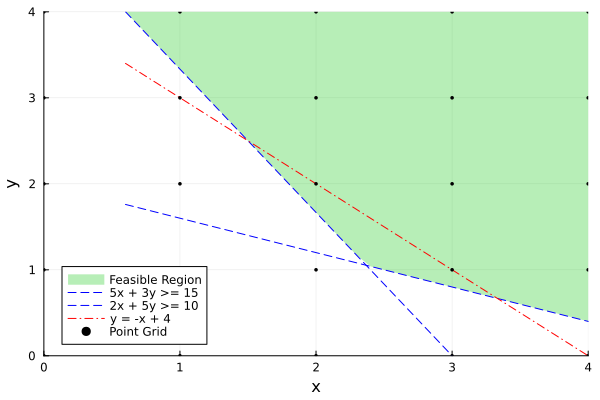

In [8]:
plot(x, y_feasible, 
    fillrange = 4,
    fillalpha = 0.35,
    fillcolor = :limegreen,
    linecolor = :transparent,    
    label="Feasible Region", 
    xlabel="x", 
    ylabel="y",
    xlims=(0,4),
    ylims=(0,4), 
    legend=:bottomleft)
plot!(x, y1.(x), linestyle=:dash, linecolor = :blue,label="5x + 3y >= 15")
plot!(x, y2.(x), linestyle=:dash, linecolor = :blue, label="2x + 5y >= 10")
plot!(x, y4.(x), linestyle=:dashdot, linecolor = :red, label="y = -x + 4")
scatter!(x_pts, y_pts,
        markersize = 2,
        color = :black,
        label = "Point Grid")